In [1]:
import math
import os
import string
from pathlib import Path

In [2]:
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

'/tmp/matplotlib'

In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator

In [4]:
mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial"],
        "font.size": 9.0,
        "axes.titlesize": 10.0,
        "axes.labelsize": 9.0,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "legend.fontsize": 8.5,
        "axes.linewidth": 0.8,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.size": 4.0,
        "xtick.major.width": 0.8,
        "ytick.major.size": 4.0,
        "ytick.major.width": 0.8,
        "xtick.minor.size": 2.0,
        "xtick.minor.width": 0.6,
        "ytick.minor.size": 2.0,
        "ytick.minor.width": 0.6,
        "xtick.minor.visible": False,
        "ytick.minor.visible": True,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
    }
)

In [5]:
SITE = "FR-Capitole"
HIST_PATTERN = f"{SITE}_hist_*.nc"
OBS_FILE = Path(f"../model_output/obs/{SITE}_clean_observations_v1.nc")

In [6]:
MODEL_SPECS = [
    {
        "key": "slab",
        "label": r"$\mathregular{Slab}$",
        "path": Path(f"/tera12/yuanhua/dongwz/point_case/JAMES/slab/{SITE}/history/{HIST_PATTERN}"),
        "color": "#DB9850",
    },
    {
        "key": "no_irr",
        "label": r"$\mathregular{Urb_{Veg}\ (No\ Irr)}$",
        "path": Path(f"/tera12/yuanhua/dongwz/point_case/JAMES/no_irr/{SITE}/history/{HIST_PATTERN}"),
        "color": "#D94738",
    },
    {
        "key": "no_ah",
        "label": r"$\mathregular{Urb_{Veg}\ (No\ AHF)}$",
        "path": Path(f"/tera12/yuanhua/dongwz/point_case/JAMES/no_ah/{SITE}/history/{HIST_PATTERN}"),
        "color": "#8A6F9E",
    },
    {
        "key": "veg",
        "label": r"$\mathregular{Urb_{Veg}}$",
        "path": Path(f"/tera12/yuanhua/dongwz/point_case/JAMES/veg/{SITE}/history/{HIST_PATTERN}"),
        "color": "#6BB48F",
    },
]

In [7]:
VARIABLE_SPECS = [
    {"obs": "SWup", "model": "f_sr", "tick": r"$SW_{up}$"},
    {"obs": "LWup", "model": "f_olrg", "tick": r"$LW_{up}$"},
    {"obs": "Qh", "model": "f_fsena", "tick": r"$Q_{h}$"},
    {"obs": "Qle", "model": "f_lfevpa", "tick": r"$Q_{le}$"},
]

In [8]:
SEASONS = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Fall": [9, 10, 11],
}

In [9]:
METRIC_ORDER = ["R", "RMSE", "MBE"]

In [10]:
def squeeze_to_time(da: xr.DataArray) -> xr.DataArray:
    out = da
    for dim in list(out.dims):
        if dim != "time":
            out = out.isel({dim: 0}, drop=True)
    return out

In [11]:
def open_model_datasets():
    datasets = {}
    for spec in MODEL_SPECS:
        datasets[spec["key"]] = xr.open_mfdataset(
            str(spec["path"]),
            combine="by_coords",
            chunks=None,
            data_vars="all",
        )
    return datasets

In [12]:
def prepare_obs_variable(obs_ds: xr.Dataset, model_ref: xr.Dataset, obs_name: str) -> xr.DataArray:
    obs = squeeze_to_time(obs_ds[obs_name].copy())
    model_solar = squeeze_to_time(model_ref["f_xy_solarin"])
    obs_swdown = squeeze_to_time(obs_ds["SWdown"])

    obs_vals = obs.values.astype(float).copy()
    swdown_vals = obs_swdown.values[: len(model_solar)]
    solar_vals = model_solar.values
    swdown_vals = np.where(solar_vals == 0, 0.0, swdown_vals)

    valid_len = min(len(obs_vals) - 1, len(swdown_vals))
    mask = np.isnan(swdown_vals[:valid_len]) | np.isnan(obs_vals[:valid_len])
    obs_vals[:valid_len] = np.where(mask, np.nan, obs_vals[:valid_len])
    if len(obs_vals) > valid_len:
        obs_vals[valid_len:] = np.nan

    return xr.DataArray(obs_vals, coords=obs.coords, dims=obs.dims, name=obs_name)

In [13]:
def to_time_dataframe(da: xr.DataArray, col_name: str, utc_offset_hours: float) -> pd.DataFrame:
    local = da.assign_coords(time=da.time + pd.Timedelta(hours=utc_offset_hours))
    df = local.to_dataframe(name=col_name).reset_index()
    return df[["time", col_name]]

In [14]:
def align_series(model_da: xr.DataArray, obs_da: xr.DataArray, model_name: str, obs_name: str, utc_offset_hours: float) -> pd.DataFrame:
    model_df = to_time_dataframe(squeeze_to_time(model_da), model_name, utc_offset_hours)
    obs_df = to_time_dataframe(squeeze_to_time(obs_da), obs_name, utc_offset_hours)
    merged = pd.merge(model_df, obs_df, on="time", how="inner")
    merged.loc[merged[obs_name].isna(), model_name] = np.nan
    return merged

In [15]:
def calc_metrics(df: pd.DataFrame, model_col: str, obs_col: str) -> dict[str, float]:
    valid = df[[model_col, obs_col]].dropna()
    if valid.empty:
        return {"R": np.nan, "RMSE": np.nan, "MBE": np.nan}

    diff = valid[model_col] - valid[obs_col]
    rmse = float(np.sqrt(np.mean(diff**2)))
    mbe = float(np.mean(diff))
    r = float(valid[model_col].corr(valid[obs_col])) if len(valid) > 1 else np.nan
    return {"R": r, "RMSE": rmse, "MBE": mbe}

In [16]:
def compute_all_metrics(model_datasets: dict[str, xr.Dataset], obs_ds: xr.Dataset) -> dict[str, dict[str, dict[str, float]]]:
    utc_offset = float(obs_ds.attrs.get("local_utc_offset_hours", 0))
    results = {season: {metric: {} for metric in METRIC_ORDER} for season in SEASONS}
    obs_cache = {}

    for var in VARIABLE_SPECS:
        obs_name = var["obs"]
        model_name = var["model"]
        obs_cache[obs_name] = prepare_obs_variable(obs_ds, model_datasets["veg"], obs_name)

        for spec in MODEL_SPECS:
            model_key = spec["key"]
            aligned = align_series(
                model_datasets[model_key][model_name],
                obs_cache[obs_name],
                model_name,
                obs_name,
                utc_offset,
            )

            for season_name, months in SEASONS.items():
                seasonal = aligned[aligned["time"].dt.month.isin(months)].copy()
                metrics = calc_metrics(seasonal, model_name, obs_name)
                for metric_name in METRIC_ORDER:
                    results[season_name][metric_name].setdefault(obs_name, {})[model_key] = metrics[metric_name]

    return results

In [17]:
def build_metric_frames(results: dict) -> dict[str, pd.DataFrame]:
    frames = {}
    for metric_name in METRIC_ORDER:
        rows = []
        for season_name in SEASONS:
            for var in VARIABLE_SPECS:
                row = {"Season": season_name, "Variable": var["obs"]}
                row.update(results[season_name][metric_name][var["obs"]])
                rows.append(row)
        frames[metric_name] = pd.DataFrame(rows)
    return frames

In [18]:
def nice_upper(value: float, step: float) -> float:
    if not np.isfinite(value) or value <= 0:
        return step
    return math.ceil(value / step) * step

In [19]:
def compute_axis_limits(results: dict) -> dict[str, tuple[float, float]]:
    metric_values = {metric: [] for metric in METRIC_ORDER}
    for season_name in SEASONS:
        for metric_name in METRIC_ORDER:
            for obs_name in results[season_name][metric_name]:
                metric_values[metric_name].extend(results[season_name][metric_name][obs_name].values())

    rmse_max = max([v for v in metric_values["RMSE"] if np.isfinite(v)], default=10.0)
    rmse_high = nice_upper(rmse_max * 1.08, 10.0)

    return {
        "R": (0.0, 1.0),
        "RMSE": (0.0, rmse_high),
        "MBE": (-60.0, 60.0),
    }

In [20]:
def add_metric_ticks(ax: plt.Axes, metric_name: str, limits: tuple[float, float]) -> None:
    if metric_name == "R":
        ax.yaxis.set_major_locator(MultipleLocator(0.2))
        ax.yaxis.set_minor_locator(MultipleLocator(0.1))
    elif metric_name == "RMSE":
        major = 10 if limits[1] <= 80 else 20
        ax.yaxis.set_major_locator(MultipleLocator(major))
        ax.yaxis.set_minor_locator(MultipleLocator(major / 2))
    else:
        span = max(abs(limits[0]), abs(limits[1]))
        major = 10 if span <= 40 else 20
        ax.yaxis.set_major_locator(MultipleLocator(major))
        ax.yaxis.set_minor_locator(MultipleLocator(major / 2))

In [21]:
def plot_results(results: dict, out_jpg: Path, out_pdf: Path) -> None:
    season_pairs = [("Winter", "Spring"), ("Summer", "Fall")]
    limits = compute_axis_limits(results)
    panel_labels = iter(string.ascii_lowercase)

    fig, axes = plt.subplots(6, 2, figsize=(6, 7.6), dpi=300, sharex=True)

    bar_width = 0.14
    x = np.arange(len(VARIABLE_SPECS))
    offsets = (np.arange(len(MODEL_SPECS)) - (len(MODEL_SPECS) - 1) / 2) * bar_width

    for block_idx, (left_season, right_season) in enumerate(season_pairs):
        for metric_idx, metric_name in enumerate(METRIC_ORDER):
            row = block_idx * 3 + metric_idx
            for col, season_name in enumerate((left_season, right_season)):
                ax = axes[row, col]
                panel_label = next(panel_labels)

                for model_idx, spec in enumerate(MODEL_SPECS):
                    values = [
                        results[season_name][metric_name][var["obs"]].get(spec["key"], np.nan)
                        for var in VARIABLE_SPECS
                    ]
                    ax.bar(
                        x + offsets[model_idx],
                        values,
                        width=bar_width,
                        color=spec["color"],
                        edgecolor="black",
                        linewidth=0.45,
                        label=spec["label"] if row == 0 and col == 0 else None,
                    )

                if metric_name == "MBE":
                    ax.axhline(0.0, color="black", linewidth=0.7)

                ax.set_ylim(*limits[metric_name])
                ax.set_xlim(-0.5, len(VARIABLE_SPECS) - 0.5)
                ax.set_title(f"({panel_label}) {metric_name}", loc="left", fontweight="bold")
                ax.set_title(season_name)
                add_metric_ticks(ax, metric_name, limits[metric_name])

                ax.tick_params(axis="x", which="major", top=False, bottom=True)
                ax.tick_params(axis="y", which="major", right=True)
                ax.tick_params(axis="y", which="minor", right=True)

                for spine in ax.spines.values():
                    spine.set_linewidth(0.8)

                if col == 0:
                    ax.set_ylabel("R" if metric_name == "R" else r"W m$^{-2}$")

                if row < axes.shape[0] - 1:
                    ax.set_xticklabels([])
                else:
                    ax.set_xticks(x)
                    ax.set_xticklabels([var["tick"] for var in VARIABLE_SPECS])

    legend_handles = [
        Patch(facecolor=spec["color"], edgecolor="black", linewidth=0.45, label=spec["label"])
        for spec in MODEL_SPECS
    ]
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=len(MODEL_SPECS),
        frameon=False,
        bbox_to_anchor=(0.55, 0.03),
        columnspacing=1.2,
        handlelength=2.5,
    )

    fig.subplots_adjust(left=0.09, right=0.99, top=0.97, bottom=0.11, wspace=0.22, hspace=0.55)
    fig.savefig(out_jpg)
    fig.savefig(out_pdf)
    plt.show()
    plt.close(fig)

In [22]:
def main():
    model_datasets = open_model_datasets()
    obs_ds = xr.open_dataset(OBS_FILE)

    results = compute_all_metrics(model_datasets, obs_ds)
    metric_frames = build_metric_frames(results)

    out_base = Path("Figure15")
    plot_results(results, out_base.with_suffix(".jpg"), out_base.with_suffix(".pdf"))

    for metric_name, frame in metric_frames.items():
        frame.to_csv(f"{out_base.stem}_{metric_name}.csv", index=False)

    obs_ds.close()
    for ds in model_datasets.values():
        ds.close()

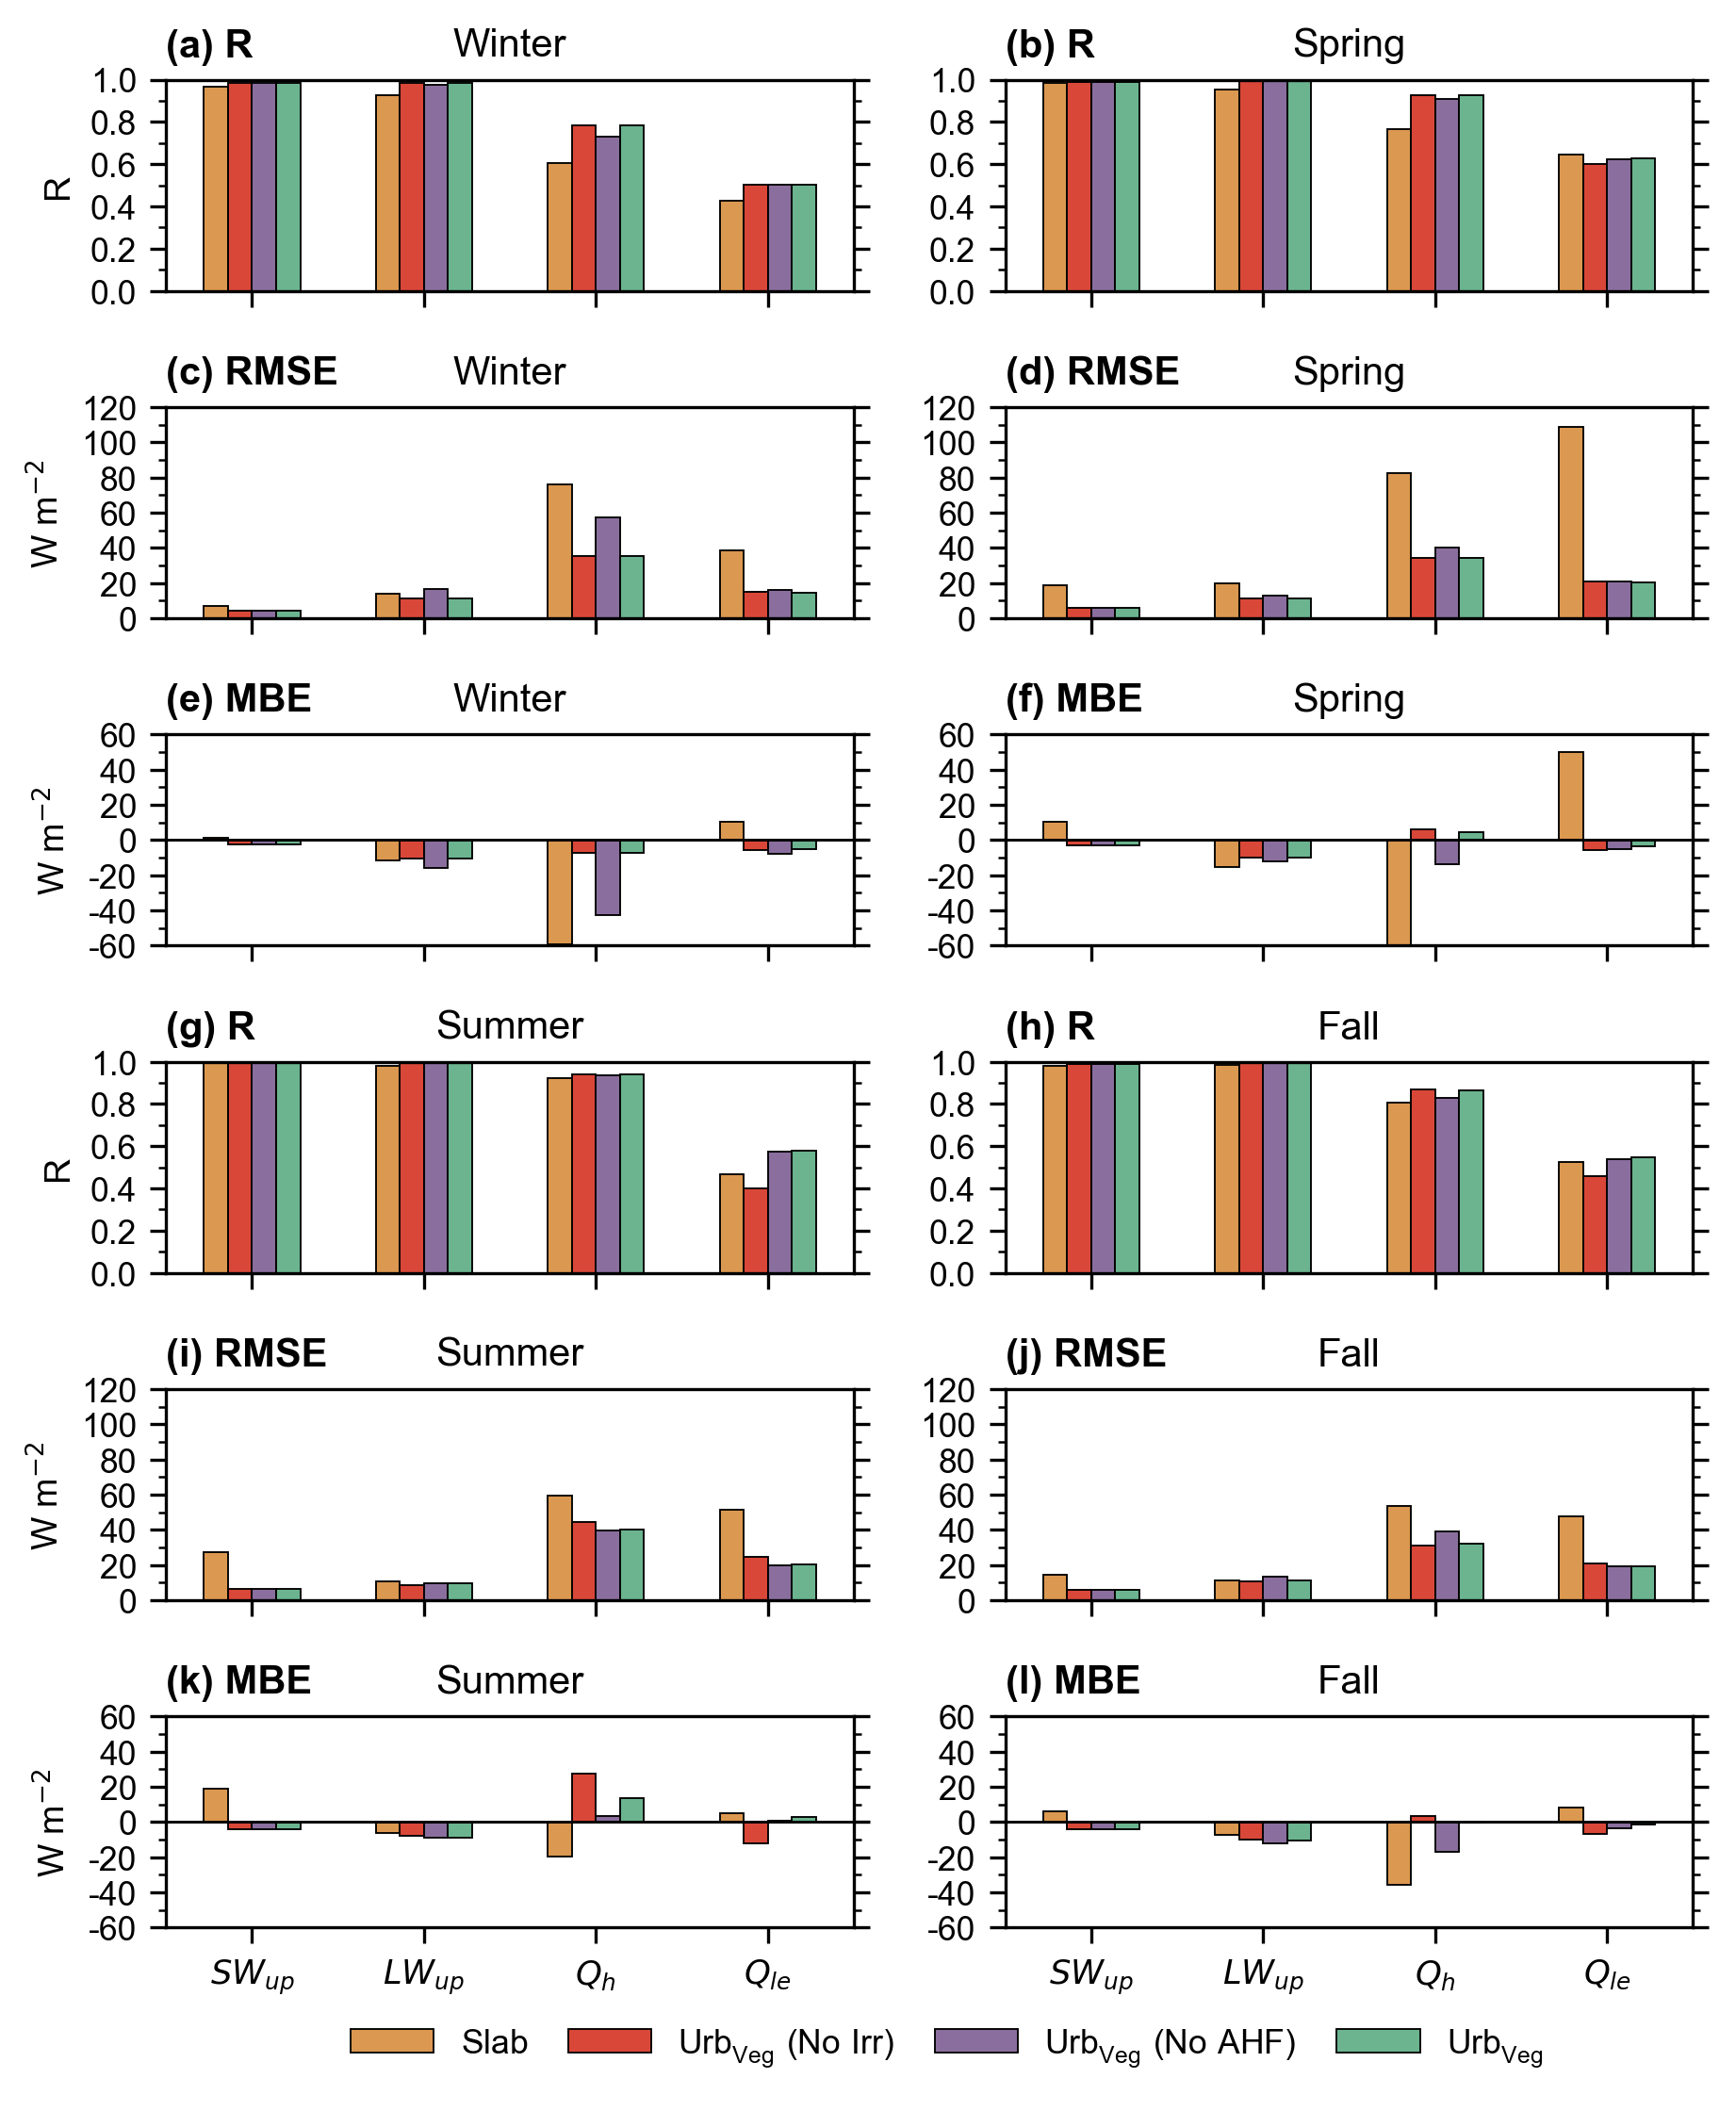

In [23]:
if __name__ == "__main__":
    main()